In [9]:
import pandas as pd
import os 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import classification_report, accuracy_score

In [10]:
#finding the path of the files for the CVSs
glcm_path = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\outputs\features\GLCM'
lbp_path = r'C:\Users\User\Desktop\Lagos-FW-2025-Analysis\Lagos-FW-2025-Analysis\outputs\features\LBP'

In [19]:
#load and fuse the data

def load_and_fuse_data(glcm_path, lbp_path):
    combined_data = []
    lbp_files ={f.lower(): f for f in os.listdir(lbp_path) if f.endswith('.csv')}

    for file_name in os.listdir(glcm_path):
        if file_name.endswith('_glcm_result.csv'):
            full_glcm_path = os.path.join(glcm_path, file_name)
            
            if os.path.getsize(full_glcm_path) == 0:
                print(f'skipping glcm file {file_name}')
                continue

            fabric = file_name.replace('_glcm_result.csv', '') #extract class names
            new_lbp = f"{fabric.lower()}_features.csv"

            if new_lbp in lbp_files:
                lbp_name = lbp_files[new_lbp]
                lbp_file_path = os.path.join(lbp_path, lbp_name) #load LBP data

            if os.path.getsize(lbp_file_path) > 0:
                glcm_df = pd.read_csv(full_glcm_path) #load glcm data
                lbp_df = pd.read_csv(lbp_file_path)

                #merging
                fused_data = pd.merge(glcm_df, lbp_df, on='filename')  # Merge on filename
                fused_data['fabric_type'] = fabric  # Add class label
                combined_data.append(fused_data)
                print("done fabric {fabric}!")
            
            else:
                print(f"no lbp found for {fabric} when looking out for {new_lbp}")

    if not combined_data:
        raise ValueError('no valid data found here')

    return pd.concat(combined_data, ignore_index=True)

In [20]:
df = load_and_fuse_data(glcm_path, lbp_path)

X = df.drop(columns=['filename','fabric_type'])
y = df['fabric_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf = svm.SVC(kernel='rbf', C=1.0, gamma='scale') #rbf is best for complex texture data
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred)*100, "%")
print(classification_report(y_test, y_pred))

done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
done fabric {fabric}!
Accuracy: 99.53917050691244 %
               precision    recall  f1-score   support

    Utilities       1.00      0.50      0.67         2
africa_fabric       1.00      1.00      1.00       215

     accuracy                           1.00       217
    macro avg       1.00      0.75      0.83       217
 weighted avg       1.00      1.00      0.99       217



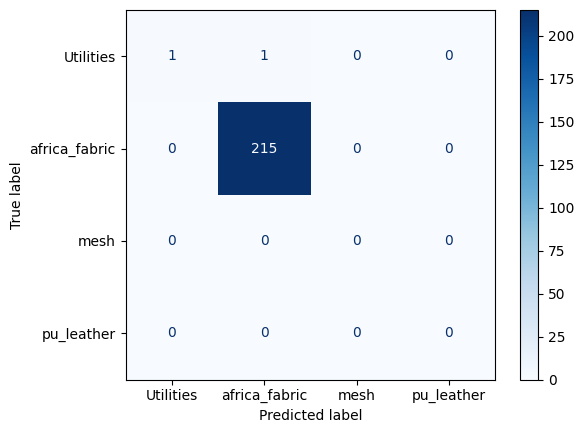

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()